# Granger Causality Test
Testing the causal direction between Synchronicity and Index Inclusion (Treatment).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# 1. Load data and construct time series for Granger Causality
# For VAR, we need time series. We will use the number of index inclusions (Treatment events) per month
# and the cross-sectional average of Synchronicity for those firms, or the market-wide Synchronicity.

panel = pd.read_parquet('../data/intermediate/panel_monthly.parquet')
events = pd.read_csv('../data/intermediate/events.csv')
events['date'] = pd.to_datetime(events['date'])
events['month'] = events['date'].dt.to_period('M')

# Inclusions (Treatment) per month
inclusions = events[events['event_type'] == 'ADD'].groupby('month').size().rename('Treatment')

# Average Synchronicity per month market-wide
panel['month'] = pd.to_datetime(panel['date']).dt.to_period('M')
synch = panel.groupby('month')['Synchronicity'].mean().rename('Synchronicity')

df = pd.concat([synch, inclusions], axis=1).fillna(0)
# Make sure index is timestamp for VAR
df.index = df.index.to_timestamp()
df = df.sort_index()

print("Time series shape:", df.shape)
df.head()


Time series shape: (151, 2)


,Synchronicity,Treatment
month,,
2013-08-01,-2.408658,0.0
2013-09-01,-2.514756,0.0
2013-10-01,-2.698430,0.0
2013-11-01,-2.979509,0.0
2013-12-01,-1.927422,0.0


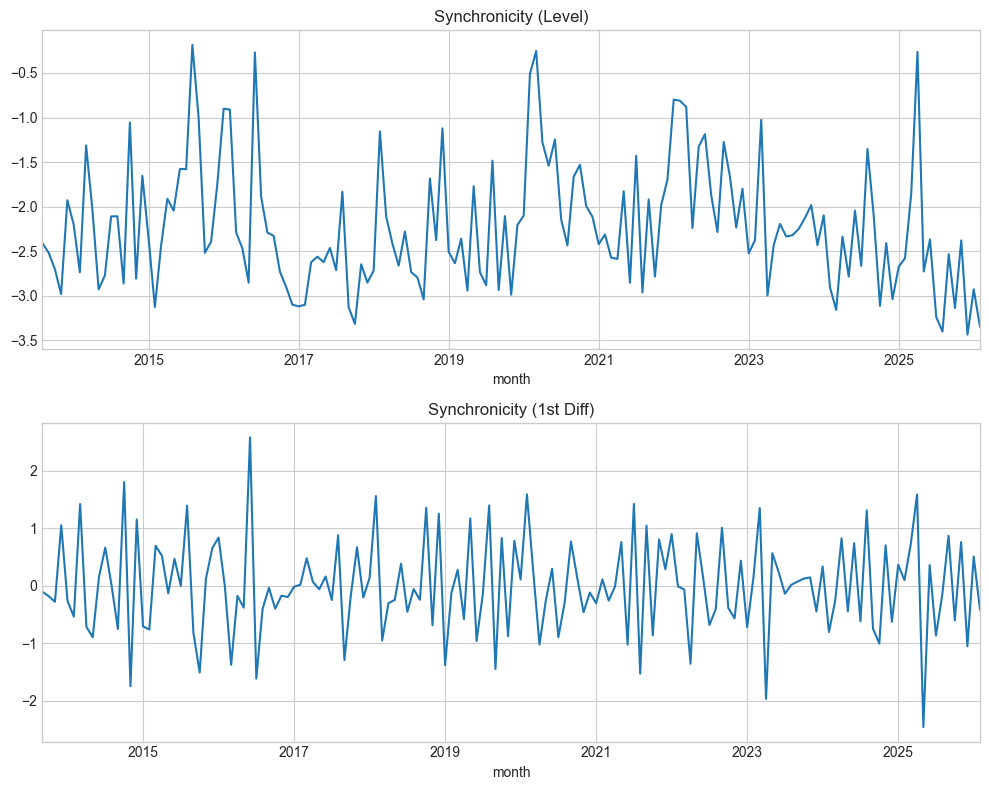

In [3]:
# 2. Stationarize the series if needed
# We assume Synchronicity and Treatment might need stationarity checks, but let's take the first difference to be safe,
# or test it directly.
df_diff = df.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
df['Synchronicity'].plot(ax=axes[0], title='Synchronicity (Level)')
df_diff['Synchronicity'].plot(ax=axes[1], title='Synchronicity (1st Diff)')
plt.tight_layout()
plt.show()


In [4]:
# 3. Fit a VAR model on (Synchronicity, Treatment) using AIC
model = VAR(df_diff[['Synchronicity', 'Treatment']])
# Select maxlag based on AIC
lag_sel = model.select_order(maxlags=15)
p_opt = lag_sel.aic
print(f"Optimal lag order (p_opt) based on AIC = {p_opt}")

results = model.fit(p_opt)
print(results.summary())


Optimal lag order (p_opt) based on AIC = 5
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 03, May, 2026
Time:                     11:34:12
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    2.36870
Nobs:                     145.000    HQIC:                   2.10057
Log likelihood:          -528.479    FPE:                    6.80486
AIC:                      1.91705    Det(Omega_mle):         5.87903
--------------------------------------------------------------------
Results for equation Synchronicity
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -0.023646         0.058926           -0.401           0.688
L1.Synchronicity        -0.649877         0.085718           -7.582           0.0

In [5]:
# 4. Granger Causality Tests
print("\n--- Granger Causality Tests (maxlag = p_opt) ---")

gc_data = df_diff[['Synchronicity', 'Treatment']]

print("\n[1] H0: Treatment does NOT Granger-cause Synchronicity")
# The second column is the causing variable being tested, first column is the caused variable
res_1 = grangercausalitytests(gc_data[['Synchronicity', 'Treatment']], maxlag=[p_opt], verbose=False)

print("\n[2] H0: Synchronicity does NOT Granger-cause Treatment")
res_2 = grangercausalitytests(gc_data[['Treatment', 'Synchronicity']], maxlag=[p_opt], verbose=False)

results_list = []
def parse_gc_res(res, p, direction):
    f_stat = res[p][0]['ssr_ftest'][0]
    p_val  = res[p][0]['ssr_ftest'][1]
    verdict = 'Reject H0 (Causality)' if p_val < 0.05 else 'Fail to Reject H0 (No Causality)'
    return {'Direction Tested': direction, 'F-stat': f_stat, 'p-value': p_val, 'Verdict (5%)': verdict}

results_list.append(parse_gc_res(res_1, p_opt, 'Treatment -> Synchronicity'))
results_list.append(parse_gc_res(res_2, p_opt, 'Synchronicity -> Treatment'))



--- Granger Causality Tests (maxlag = p_opt) ---

[1] H0: Treatment does NOT Granger-cause Synchronicity

[2] H0: Synchronicity does NOT Granger-cause Treatment


In [6]:
# 5. Test residual serial correlation (Ljung-Box)
resid = results.resid

lb_synch = acorr_ljungbox(resid['Synchronicity'], lags=[p_opt])
lb_treat = acorr_ljungbox(resid['Treatment'], lags=[p_opt])

print("\nLjung-Box Test on Residuals (H0: No serial correlation)")
print(f"Synchronicity: p-val = {lb_synch['lb_pvalue'].values[0]:.4f}")
print(f"Treatment:     p-val = {lb_treat['lb_pvalue'].values[0]:.4f}")



Ljung-Box Test on Residuals (H0: No serial correlation)
Synchronicity: p-val = 0.7925
Treatment:     p-val = 0.9424


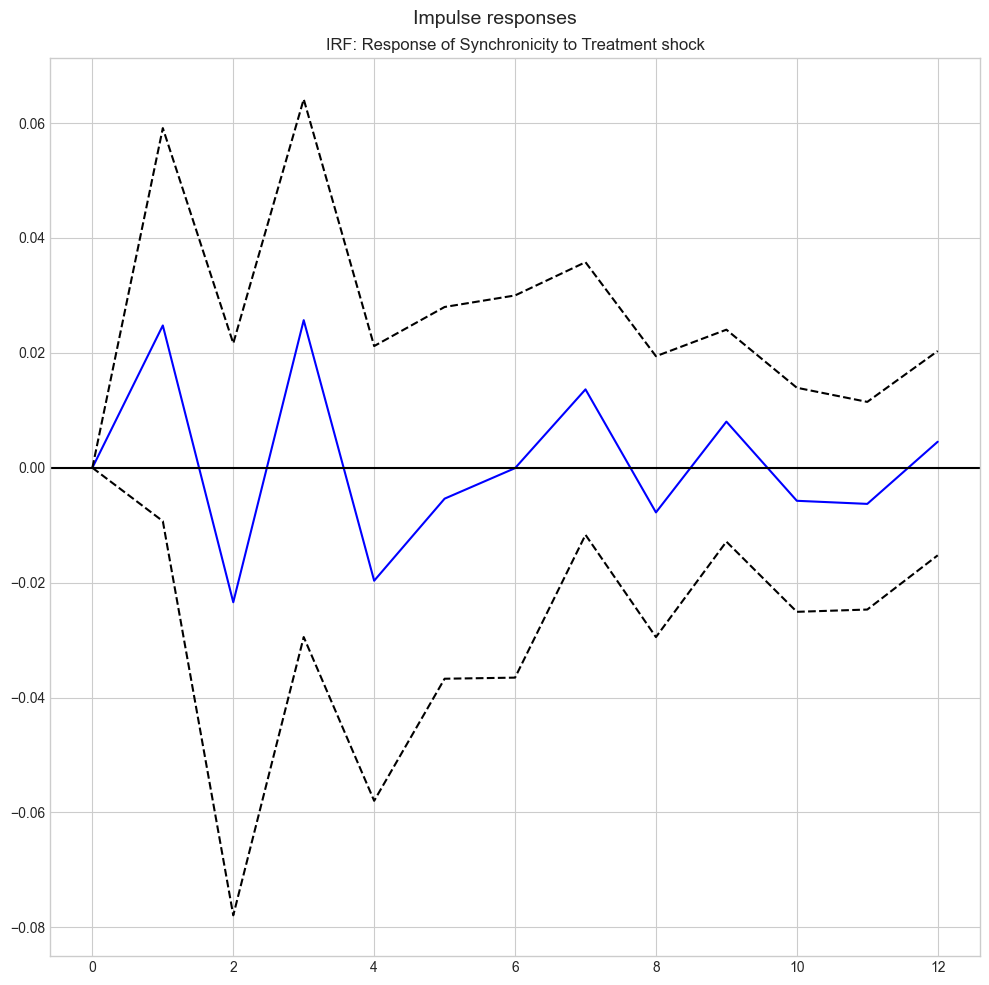

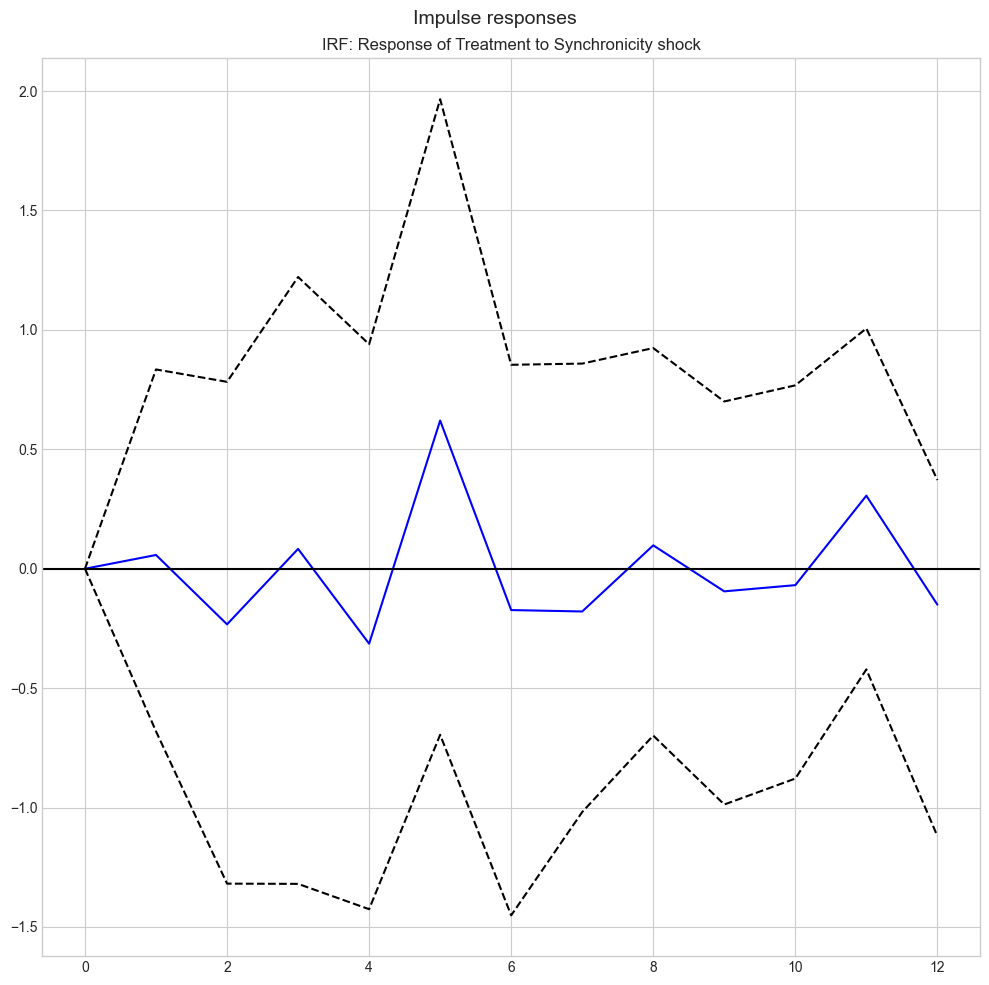

In [7]:
# 6. Plot IRF
out_dir = Path('../figures/granger_causality')
out_dir.mkdir(parents=True, exist_ok=True)

irf = results.irf(12)
fig = irf.plot(impulse='Treatment', response='Synchronicity', stderr_type='mc', repl=100)
plt.title("IRF: Response of Synchronicity to Treatment shock")
plt.tight_layout()
plt.savefig(out_dir / "irf_treatment_to_synchronicity.png")
plt.show()

# Also save the other direction
fig2 = irf.plot(impulse='Synchronicity', response='Treatment', stderr_type='mc', repl=100)
plt.title("IRF: Response of Treatment to Synchronicity shock")
plt.tight_layout()
plt.savefig(out_dir / "irf_synchronicity_to_treatment.png")
plt.show()


In [8]:
# 7. Output clean summary table
summary_df = pd.DataFrame(results_list)
summary_df


,Direction Tested,F-stat,p-value,Verdict (5%)
0,Treatment -> Synchronicity,0.918801,0.470941,Fail to Reject H0 (No Causality)
1,Synchronicity -> Treatment,0.364530,0.872064,Fail to Reject H0 (No Causality)
